
# Reproduction of Kveton et al. (2015)

This notebook implements the **original Section 7 experiment** from:

> Kveton, Wen, Ashkan, and Szepesvári, *Tight Regret Bounds for Stochastic Combinatorial Semi-Bandits*, AISTATS 2015.

It reproduces the paper's grid-path stochastic combinatorial semi-bandit experiment:

\[
L = 2m(m+1), \qquad K = 2m,
\]

where each action is a monotone directed path from the upper-left corner to the lower-right corner of an \((m+1)\times(m+1)\) grid. The edge means are exactly the Section 7 construction:

\[
\bar w(e)=
\begin{cases}
0.5+\Delta/2, & e \text{ is a leftmost or bottommost edge},\\
0.5-\Delta/2, & \text{otherwise}.
\end{cases}
\]

The main output is a strict Figure 1(c)-style plot: **final n-step regret at \(n=10^5\)** versus the number of ground items \(L\), with one curve for each \(\Delta\in\{0.8,0.4,0.2\}\).

Important distinction:

- The paper's Figure 1(c) has **x-axis = number of items \(L\)**.
- A cumulative-regret-over-time curve is useful for debugging, but it is **not** Figure 1(c).


In [1]:

import os
import math
import pickle
import time
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from numba import njit

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
})

OUT_DIR = "figurs/reproduce_outputs_strict"
CACHE_DIR = os.path.join(OUT_DIR, "cache")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)



## Experiment controls

`STRICT_MODE=True` uses the paper's horizon \(n=10^5\). The implementation uses a Numba-compiled exact dynamic-programming oracle, so the strict experiment should still be practical on a normal laptop.

Use `STRICT_MODE=False` only for a quick smoke test.


In [2]:

STRICT_MODE = True

if STRICT_MODE:
    N_STEPS = 100_000          # paper: n = 10^5
    NUM_RUNS = 20              # independent Monte Carlo repetitions
    M_VALUES = [3, 4, 5, 6, 7] # L = 24, 40, 60, 84, 112
    DELTAS = [0.8, 0.4, 0.2]
else:
    N_STEPS = 5_000
    NUM_RUNS = 3
    M_VALUES = [3, 4, 5]
    DELTAS = [0.8, 0.4, 0.2]

BASE_SEED = 20260511
print({"STRICT_MODE": STRICT_MODE, "N_STEPS": N_STEPS, "NUM_RUNS": NUM_RUNS, "M_VALUES": M_VALUES, "DELTAS": DELTAS})


{'STRICT_MODE': True, 'N_STEPS': 100000, 'NUM_RUNS': 20, 'M_VALUES': [3, 4, 5, 6, 7], 'DELTAS': [0.8, 0.4, 0.2]}



## Exact grid-path instance

The directed grid has two edge types:

- down edges: \((i,j)\to(i+1,j)\),
- right edges: \((i,j)\to(i,j+1)\).

There are \(m(m+1)\) down edges and \(m(m+1)\) right edges, hence

\[
L=2m(m+1).
\]

Every feasible path uses \(m\) down moves and \(m\) right moves, hence

\[
K=2m.
\]

The optimal path is the leftmost column followed by the bottom row.


In [3]:

@dataclass
class GridPathInstance:
    m: int
    delta: float
    down_idx: np.ndarray
    right_idx: np.ndarray
    means: np.ndarray
    good_edges: np.ndarray
    optimal_path: np.ndarray
    optimal_value: float

    @property
    def L(self) -> int:
        return int(self.means.shape[0])

    @property
    def K(self) -> int:
        return 2 * self.m


def build_grid_path_instance(m: int, delta: float) -> GridPathInstance:
    """Build the exact Section 7 grid-path instance from Kveton et al. (2015)."""
    L = 2 * m * (m + 1)
    down_idx = np.empty((m, m + 1), dtype=np.int64)
    right_idx = np.empty((m + 1, m), dtype=np.int64)
    means = np.empty(L, dtype=np.float64)
    good_edges = np.zeros(L, dtype=np.bool_)

    idx = 0
    # Down edges: (i,j) -> (i+1,j)
    for i in range(m):
        for j in range(m + 1):
            down_idx[i, j] = idx
            good = (j == 0)  # leftmost down edge
            good_edges[idx] = good
            means[idx] = 0.5 + delta / 2 if good else 0.5 - delta / 2
            idx += 1

    # Right edges: (i,j) -> (i,j+1)
    for i in range(m + 1):
        for j in range(m):
            right_idx[i, j] = idx
            good = (i == m)  # bottommost right edge
            good_edges[idx] = good
            means[idx] = 0.5 + delta / 2 if good else 0.5 - delta / 2
            idx += 1

    optimal_path = []
    for i in range(m):
        optimal_path.append(down_idx[i, 0])
    for j in range(m):
        optimal_path.append(right_idx[m, j])
    optimal_path = np.asarray(optimal_path, dtype=np.int64)
    optimal_value = float(means[optimal_path].sum())

    return GridPathInstance(m, delta, down_idx, right_idx, means, good_edges, optimal_path, optimal_value)

for m in [3, 4, 7]:
    inst = build_grid_path_instance(m, 0.4)
    assert inst.L == 2 * m * (m + 1)
    assert inst.K == 2 * m
    assert inst.optimal_path.shape[0] == inst.K
print("Grid-path instance checks passed.")


Grid-path instance checks passed.



## Exact offline oracle

CombUCB1 chooses

\[
A_t = \arg\max_{A\in\Theta}\sum_{e\in A} U_t(e).
\]

For a monotone grid path, this is an exact longest-path problem in a directed acyclic graph. The next cell implements the oracle with dynamic programming and compiles it using Numba.


In [4]:

@njit(cache=True)
def max_weight_path_oracle_numba(weights: np.ndarray, down_idx: np.ndarray, right_idx: np.ndarray, m: int) -> np.ndarray:
    """Exact maximum-weight monotone path oracle."""
    neg = -1e18
    dp = np.empty((m + 1, m + 1), dtype=np.float64)
    prev = np.zeros((m + 1, m + 1), dtype=np.int64)  # 1 = came from up via down edge; 2 = came from left via right edge

    for i in range(m + 1):
        for j in range(m + 1):
            dp[i, j] = neg
    dp[0, 0] = 0.0

    for i in range(m + 1):
        for j in range(m + 1):
            cur = dp[i, j]
            if i < m:
                e = down_idx[i, j]
                cand = cur + weights[e]
                if cand > dp[i + 1, j]:
                    dp[i + 1, j] = cand
                    prev[i + 1, j] = 1
            if j < m:
                e = right_idx[i, j]
                cand = cur + weights[e]
                if cand > dp[i, j + 1]:
                    dp[i, j + 1] = cand
                    prev[i, j + 1] = 2

    path = np.empty(2 * m, dtype=np.int64)
    i = m
    j = m
    pos = 2 * m - 1
    while i != 0 or j != 0:
        direction = prev[i, j]
        if direction == 1:
            e = down_idx[i - 1, j]
            i -= 1
        else:
            e = right_idx[i, j - 1]
            j -= 1
        path[pos] = e
        pos -= 1
    return path

# Compile and sanity-check oracle.
for m in [3, 4, 7]:
    for delta in [0.2, 0.4, 0.8]:
        inst = build_grid_path_instance(m, delta)
        path = max_weight_path_oracle_numba(inst.means, inst.down_idx, inst.right_idx, inst.m)
        assert np.array_equal(path, inst.optimal_path)
print("Oracle checks passed.")


Oracle checks passed.



## CombUCB1 implementation

The implementation follows Algorithm 1 and Algorithm 2 in the paper.

### Initialization

The paper's `Init` procedure does **not** observe edges independently. It repeatedly calls the feasible-action oracle with auxiliary weights \(u(e)\). Initially \(u(e)=1\) for all edges; after an edge is observed, \(u(e)=0\). This continues until every edge has been observed at least once.

### Main UCB loop

At each step, the algorithm computes

\[
U_t(e)=\hat w_{T_{t-1}(e)}(e)+\sqrt{\frac{1.5\log(t-1)}{T_{t-1}(e)}}
\]

and then calls the exact maximum-weight path oracle.


In [5]:

@njit(cache=True)
def run_combucb1_numba(
    m: int,
    means: np.ndarray,
    down_idx: np.ndarray,
    right_idx: np.ndarray,
    optimal_value: float,
    n_steps: int,
    seed: int,
) -> float:
    """Run CombUCB1 and return expected cumulative regret.

    Regret is evaluated as f(A*, mean) - f(A_t, mean), which is the expected
    instantaneous regret. The algorithm itself observes Bernoulli samples.
    """
    np.random.seed(seed)
    L = means.shape[0]
    K = 2 * m

    # Algorithm 2: Init
    aux = np.ones(L, dtype=np.float64)
    w_hat = np.zeros(L, dtype=np.float64)
    observed = np.zeros(L, dtype=np.bool_)
    observed_count = 0
    total_regret = 0.0
    t_count = 0
    safety = 0

    while observed_count < L:
        path = max_weight_path_oracle_numba(aux, down_idx, right_idx, m)
        path_value = 0.0
        for k in range(K):
            e = path[k]
            path_value += means[e]
            reward = 1.0 if np.random.random() < means[e] else 0.0
            w_hat[e] = reward
            if not observed[e]:
                observed[e] = True
                observed_count += 1
            aux[e] = 0.0
        total_regret += optimal_value - path_value
        t_count += 1
        safety += 1
        if safety > 10 * L:
            # Should never happen because every edge belongs to some feasible path.
            break

    # As in Algorithm 1 after Init: T_{t0-1}(e) = 1 for every item.
    counts = np.ones(L, dtype=np.int64)

    # Algorithm 1: UCB loop
    while t_count < n_steps:
        log_time = np.log(t_count if t_count > 2 else 2.0)
        ucb = np.empty(L, dtype=np.float64)
        for e in range(L):
            ucb[e] = w_hat[e] + np.sqrt(1.5 * log_time / counts[e])

        path = max_weight_path_oracle_numba(ucb, down_idx, right_idx, m)
        path_value = 0.0
        for k in range(K):
            path_value += means[path[k]]
        total_regret += optimal_value - path_value

        # Semi-bandit feedback: observe selected edge rewards only.
        for k in range(K):
            e = path[k]
            reward = 1.0 if np.random.random() < means[e] else 0.0
            old_count = counts[e]
            counts[e] = old_count + 1
            w_hat[e] = (old_count * w_hat[e] + reward) / counts[e]

        t_count += 1

    return total_regret


@njit(cache=True)
def run_combucb1_curve_numba(
    m: int,
    means: np.ndarray,
    down_idx: np.ndarray,
    right_idx: np.ndarray,
    optimal_value: float,
    n_steps: int,
    seed: int,
) -> np.ndarray:
    """Same algorithm, but returns cumulative regret over time for diagnostics."""
    np.random.seed(seed)
    L = means.shape[0]
    K = 2 * m
    curve = np.zeros(n_steps, dtype=np.float64)

    aux = np.ones(L, dtype=np.float64)
    w_hat = np.zeros(L, dtype=np.float64)
    observed = np.zeros(L, dtype=np.bool_)
    observed_count = 0
    total_regret = 0.0
    t_count = 0

    while observed_count < L and t_count < n_steps:
        path = max_weight_path_oracle_numba(aux, down_idx, right_idx, m)
        path_value = 0.0
        for k in range(K):
            e = path[k]
            path_value += means[e]
            reward = 1.0 if np.random.random() < means[e] else 0.0
            w_hat[e] = reward
            if not observed[e]:
                observed[e] = True
                observed_count += 1
            aux[e] = 0.0
        total_regret += optimal_value - path_value
        curve[t_count] = total_regret
        t_count += 1

    counts = np.ones(L, dtype=np.int64)

    while t_count < n_steps:
        log_time = np.log(t_count if t_count > 2 else 2.0)
        ucb = np.empty(L, dtype=np.float64)
        for e in range(L):
            ucb[e] = w_hat[e] + np.sqrt(1.5 * log_time / counts[e])
        path = max_weight_path_oracle_numba(ucb, down_idx, right_idx, m)
        path_value = 0.0
        for k in range(K):
            path_value += means[path[k]]
        total_regret += optimal_value - path_value
        for k in range(K):
            e = path[k]
            reward = 1.0 if np.random.random() < means[e] else 0.0
            old_count = counts[e]
            counts[e] = old_count + 1
            w_hat[e] = (old_count * w_hat[e] + reward) / counts[e]
        curve[t_count] = total_regret
        t_count += 1

    return curve

# Compile and smoke test.
inst = build_grid_path_instance(3, 0.4)
smoke = run_combucb1_numba(inst.m, inst.means, inst.down_idx, inst.right_idx, inst.optimal_value, 200, BASE_SEED)
assert np.isfinite(smoke) and smoke >= -1e-9
print("CombUCB1 compiled and smoke-tested. Example 200-step regret:", round(smoke, 3))


CombUCB1 compiled and smoke-tested. Example 200-step regret: 144.0



## Optional Figure 1(a) and Figure 1(b) illustrations

These are included only to help the report explanation. The main numerical reproduction is Figure 1(c).


saved figurs/reproduce_outputs_strict/reproduce_fig1a_k_path_diagram.png
saved figurs/reproduce_outputs_strict/reproduce_fig1b_grid_path_diagram.png


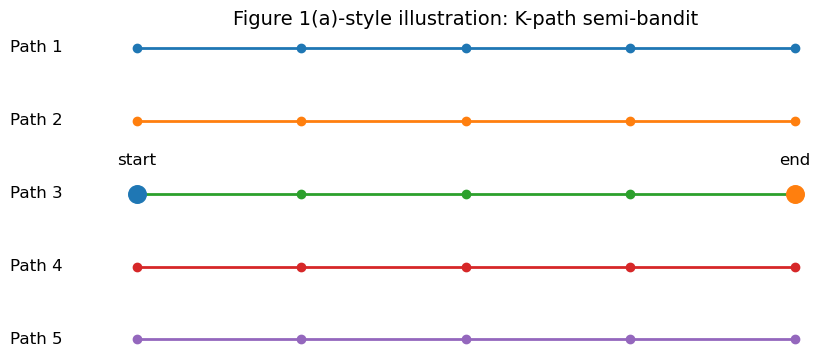

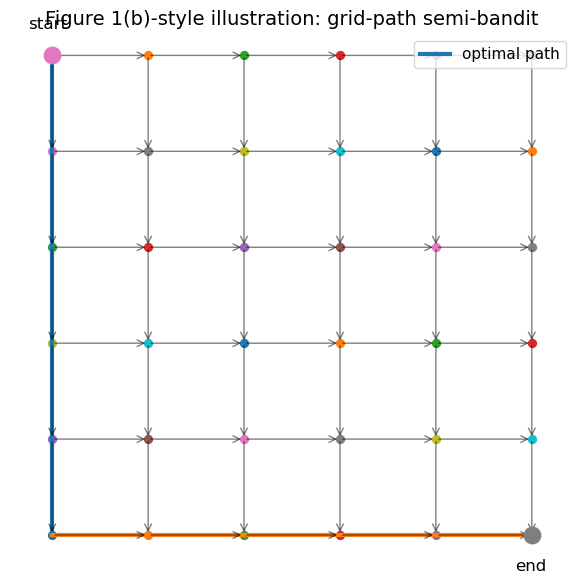

In [6]:

def plot_k_path_diagram(K: int = 4, num_paths: int = 5, save: bool = True):
    fig, ax = plt.subplots(figsize=(8.5, 3.8))
    for p in range(num_paths):
        y = num_paths - 1 - p
        xs = np.arange(K + 1)
        ax.plot(xs, np.full_like(xs, y), marker='o', linewidth=2)
        ax.text(-0.45, y, f"Path {p+1}", ha="right", va="center")
    ax.scatter([0], [num_paths - 3], s=160, zorder=5)
    ax.scatter([K], [num_paths - 3], s=160, zorder=5)
    ax.text(0, num_paths - 2.6, "start", ha="center")
    ax.text(K, num_paths - 2.6, "end", ha="center")
    ax.set_title("Figure 1(a)-style illustration: K-path semi-bandit")
    ax.axis("off")
    fig.tight_layout()
    if save:
        path = os.path.join(OUT_DIR, "reproduce_fig1a_k_path_diagram.png")
        fig.savefig(path, dpi=200, bbox_inches="tight")
        print("saved", path)
    return fig, ax


def plot_grid_path_diagram(m: int = 5, save: bool = True):
    inst = build_grid_path_instance(m, 0.4)
    fig, ax = plt.subplots(figsize=(6, 6))

    # All edges.
    for i in range(m):
        for j in range(m + 1):
            ax.annotate("", xy=(j, -(i + 1)), xytext=(j, -i), arrowprops=dict(arrowstyle="->", lw=1.0, alpha=0.5))
    for i in range(m + 1):
        for j in range(m):
            ax.annotate("", xy=(j + 1, -i), xytext=(j, -i), arrowprops=dict(arrowstyle="->", lw=1.0, alpha=0.5))

    # Optimal path.
    ax.plot([0, 0], [0, -m], linewidth=3, label="optimal path")
    ax.plot([0, m], [-m, -m], linewidth=3)

    for i in range(m + 1):
        for j in range(m + 1):
            ax.scatter(j, -i, s=32)
    ax.scatter(0, 0, s=140, zorder=5)
    ax.scatter(m, -m, s=140, zorder=5)
    ax.text(-0.25, 0.25, "start", ha="left", va="bottom")
    ax.text(m + 0.15, -m - 0.25, "end", ha="right", va="top")
    ax.legend(loc="upper right")
    ax.set_title("Figure 1(b)-style illustration: grid-path semi-bandit")
    ax.axis("equal")
    ax.axis("off")
    fig.tight_layout()
    if save:
        path = os.path.join(OUT_DIR, "reproduce_fig1b_grid_path_diagram.png")
        fig.savefig(path, dpi=200, bbox_inches="tight")
        print("saved", path)
    return fig, ax

plot_k_path_diagram();
plot_grid_path_diagram();



## Run the strict Figure 1(c) experiment

For each pair \((m,\Delta)\), the code runs CombUCB1 for \(n=10^5\) steps and records the final expected cumulative regret. Results are cached, so rerunning the notebook does not repeat finished settings.


In [7]:

def cache_path_for(m: int, delta: float, n_steps: int, num_runs: int) -> str:
    return os.path.join(CACHE_DIR, f"strict_m{m}_delta{delta}_n{n_steps}_runs{num_runs}.pkl")


def run_setting(m: int, delta: float, n_steps: int, num_runs: int, base_seed: int, use_cache: bool = True):
    cache_path = cache_path_for(m, delta, n_steps, num_runs)
    if use_cache and os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    inst = build_grid_path_instance(m, delta)
    regrets = []
    start = time.time()
    for r in range(num_runs):
        seed = base_seed + 100_000 * r + 1_000 * m + int(round(100 * delta))
        reg = run_combucb1_numba(inst.m, inst.means, inst.down_idx, inst.right_idx, inst.optimal_value, n_steps, seed)
        regrets.append(reg)
    regrets = np.asarray(regrets, dtype=float)
    result = {
        "m": m,
        "L": inst.L,
        "K": inst.K,
        "delta": delta,
        "n_steps": n_steps,
        "num_runs": num_runs,
        "mean_regret": float(regrets.mean()),
        "se_regret": float(regrets.std(ddof=1) / math.sqrt(num_runs)) if num_runs > 1 else 0.0,
        "all_regrets": regrets,
        "runtime_sec": time.time() - start,
    }
    if use_cache:
        with open(cache_path, "wb") as f:
            pickle.dump(result, f)
    return result


def run_figure_1c_experiment():
    rows = []
    total = len(DELTAS) * len(M_VALUES)
    done = 0
    start = time.time()
    for delta in DELTAS:
        for m in M_VALUES:
            done += 1
            print(f"[{done}/{total}] delta={delta}, m={m}, L={2*m*(m+1)}")
            res = run_setting(m, delta, N_STEPS, NUM_RUNS, BASE_SEED, use_cache=True)
            rows.append(res)
            print(f"    mean regret={res['mean_regret']:.1f}, SE={res['se_regret']:.1f}, runtime={res['runtime_sec']:.2f}s")
    print(f"Total wall time: {time.time() - start:.2f}s")
    return rows

results = run_figure_1c_experiment()
results[:2]


[1/15] delta=0.8, m=3, L=24
    mean regret=375.9, SE=3.2, runtime=0.36s
[2/15] delta=0.8, m=4, L=40
    mean regret=667.5, SE=4.5, runtime=0.40s
[3/15] delta=0.8, m=5, L=60
    mean regret=1036.4, SE=4.4, runtime=0.50s
[4/15] delta=0.8, m=6, L=84
    mean regret=1498.9, SE=4.7, runtime=0.66s
[5/15] delta=0.8, m=7, L=112
    mean regret=2020.0, SE=5.5, runtime=0.70s
[6/15] delta=0.4, m=3, L=24
    mean regret=707.3, SE=10.0, runtime=0.39s
[7/15] delta=0.4, m=4, L=40
    mean regret=1262.7, SE=9.3, runtime=0.45s
[8/15] delta=0.4, m=5, L=60
    mean regret=1946.3, SE=12.8, runtime=0.53s
[9/15] delta=0.4, m=6, L=84
    mean regret=2798.1, SE=16.0, runtime=0.60s
[10/15] delta=0.4, m=7, L=112
    mean regret=3845.7, SE=21.8, runtime=0.71s
[11/15] delta=0.2, m=3, L=24
    mean regret=1328.0, SE=17.7, runtime=0.42s
[12/15] delta=0.2, m=4, L=40
    mean regret=2339.1, SE=21.7, runtime=0.42s
[13/15] delta=0.2, m=5, L=60
    mean regret=3673.2, SE=32.9, runtime=0.52s
[14/15] delta=0.2, m=6, L=84

[{'m': 3,
  'L': 24,
  'K': 6,
  'delta': 0.8,
  'n_steps': 100000,
  'num_runs': 20,
  'mean_regret': 375.88000000000017,
  'se_regret': 3.168409861844196,
  'all_regrets': array([374.4, 381.6, 366.4, 393.6, 355.2, 380.8, 375.2, 378.4, 379.2,
         399.2, 392.8, 384. , 364. , 380. , 396. , 371.2, 342.4, 374.4,
         360. , 368.8]),
  'runtime_sec': 0.3648228645324707},
 {'m': 4,
  'L': 40,
  'K': 8,
  'delta': 0.8,
  'n_steps': 100000,
  'num_runs': 20,
  'mean_regret': 667.5199999999999,
  'se_regret': 4.542718870549011,
  'all_regrets': array([668.8, 681.6, 654.4, 691.2, 689.6, 712. , 638.4, 689.6, 653.6,
         674.4, 646.4, 666.4, 681.6, 649.6, 666.4, 683.2, 667.2, 656. ,
         638.4, 641.6]),
  'runtime_sec': 0.4029357433319092}]

saved figurs/reproduce_outputs_strict/reproduce_strict_fig1c_regret_vs_L.png


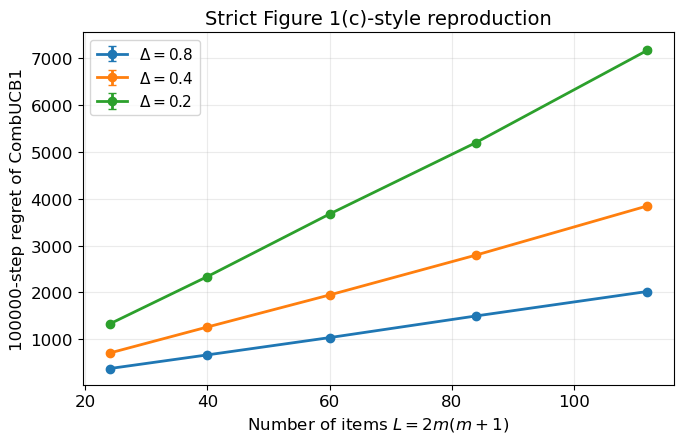

In [8]:

def plot_figure_1c(results, save: bool = True):
    fig, ax = plt.subplots(figsize=(7.0, 4.6))
    for delta in DELTAS:
        subset = sorted([r for r in results if abs(r["delta"] - delta) < 1e-12], key=lambda x: x["L"])
        xs = np.asarray([r["L"] for r in subset])
        ys = np.asarray([r["mean_regret"] for r in subset])
        ses = np.asarray([r["se_regret"] for r in subset])
        ax.errorbar(xs, ys, yerr=ses, marker="o", linewidth=2, capsize=3, label=fr"$\Delta={delta}$")

    ax.set_xlabel(r"Number of items $L=2m(m+1)$")
    ax.set_ylabel(fr"{N_STEPS}-step regret of CombUCB1")
    ax.set_title("Strict Figure 1(c)-style reproduction")
    ax.legend(frameon=True)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    if save:
        path = os.path.join(OUT_DIR, "reproduce_strict_fig1c_regret_vs_L.png")
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("saved", path)
    return fig, ax

plot_figure_1c(results);



## Additional diagnostic: regret versus inverse gap

This diagnostic checks the paper's second stated trend by fixing \(m\) and plotting final regret against \(1/\Delta\). It is useful, but the main Figure 1(c)-style reproduction is the previous plot.


saved figurs/reproduce_outputs_strict/reproduce_strict_inverse_gap_diagnostic.png


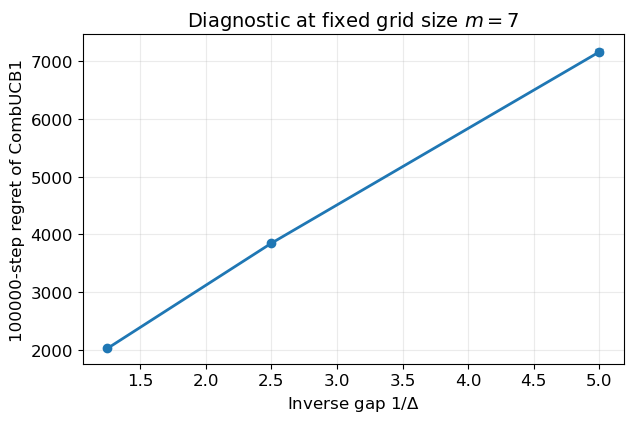

In [9]:

def plot_inverse_gap_diagnostic(results, fixed_m: Optional[int] = None, save: bool = True):
    if fixed_m is None:
        fixed_m = M_VALUES[-1]
    subset = sorted([r for r in results if r["m"] == fixed_m], key=lambda x: 1.0 / x["delta"])
    xs = np.asarray([1.0 / r["delta"] for r in subset])
    ys = np.asarray([r["mean_regret"] for r in subset])
    ses = np.asarray([r["se_regret"] for r in subset])

    fig, ax = plt.subplots(figsize=(6.5, 4.4))
    ax.errorbar(xs, ys, yerr=ses, marker="o", linewidth=2, capsize=3)
    ax.set_xlabel(r"Inverse gap $1/\Delta$")
    ax.set_ylabel(fr"{N_STEPS}-step regret of CombUCB1")
    ax.set_title(fr"Diagnostic at fixed grid size $m={fixed_m}$")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    if save:
        path = os.path.join(OUT_DIR, "reproduce_strict_inverse_gap_diagnostic.png")
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("saved", path)
    return fig, ax

plot_inverse_gap_diagnostic(results);



## Optional auxiliary learning curve

This is only for explanation/debugging. Do **not** label this as Figure 1(c), because Figure 1(c) uses \(L\), not round number, on the x-axis.


saved figurs/reproduce_outputs_strict/reproduce_aux_cumulative_regret_over_time.png


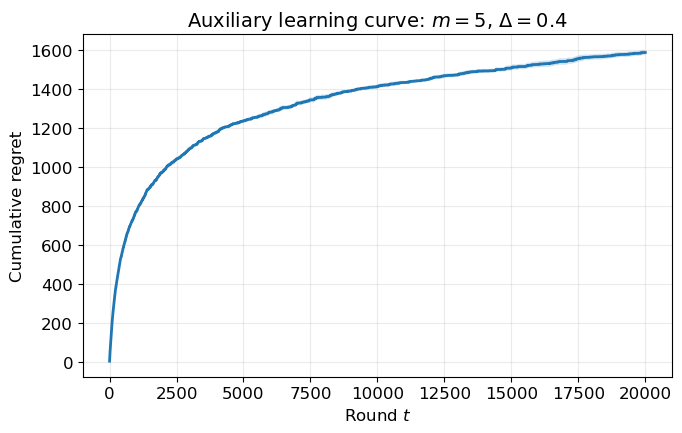

In [10]:

def plot_auxiliary_learning_curve(m: int = 5, delta: float = 0.4, n_steps: int = 20_000, num_runs: int = 5, save: bool = True):
    inst = build_grid_path_instance(m, delta)
    curves = []
    for r in range(num_runs):
        seed = BASE_SEED + 777_000 + r
        curve = run_combucb1_curve_numba(inst.m, inst.means, inst.down_idx, inst.right_idx, inst.optimal_value, n_steps, seed)
        curves.append(curve)
    curves = np.vstack(curves)
    mean = curves.mean(axis=0)
    se = curves.std(axis=0, ddof=1) / math.sqrt(num_runs) if num_runs > 1 else np.zeros_like(mean)
    x = np.arange(1, n_steps + 1)

    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    ax.plot(x, mean, linewidth=2)
    ax.fill_between(x, mean - se, mean + se, alpha=0.2)
    ax.set_xlabel("Round $t$")
    ax.set_ylabel("Cumulative regret")
    ax.set_title(fr"Auxiliary learning curve: $m={m}$, $\Delta={delta}$")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    if save:
        path = os.path.join(OUT_DIR, "reproduce_aux_cumulative_regret_over_time.png")
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("saved", path)
    return fig, ax

plot_auxiliary_learning_curve();
